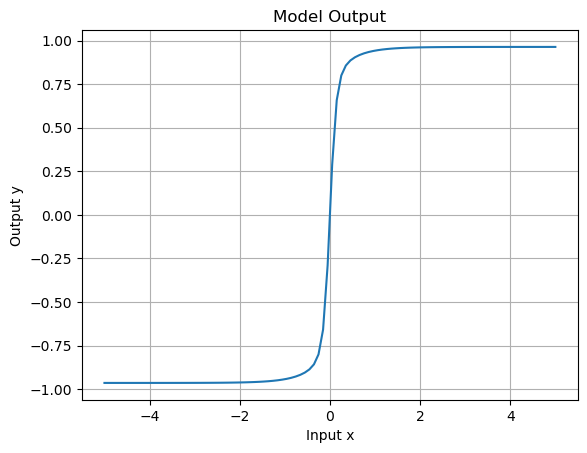

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def MLP(x, w1,w2,b1,b2,W1,W2,c):
    h1 = np.tanh(x*w1 + b1)
    h2 = np.tanh(x*w2 + b2)
    y = np.tanh(h1*W1 + h2*W2 + c)
    return y

class Model:
    def __init__(self, w1, w2, b1, b2, W1, W2, c):
        self.w1 = w1
        self.w2 = w2
        self.b1 = b1
        self.b2 = b2
        self.W1 = W1
        self.W2 = W2
        self.c = c

    def __call__(self, x):
        return MLP(x, self.w1, self.w2, self.b1, self.b2, self.W1, self.W2, self.c)

def plot_model():
    x = np.linspace(-5, 5, 100)
    model = Model(1.0, -5.0, 0.0, 0.0, 1.0, -1.0, 0.0)
    y = model(x)

    plt.plot(x, y)
    plt.title('Model Output')
    plt.xlabel('Input x')
    plt.ylabel('Output y')
    plt.grid()
    plt.show()

plot_model()

In [20]:
w1 = 1.0
w2 = 1.0
W1 = 1.0
W2 = 1.0
b1 = 0.0
b2 = 0.0
c = 0.0

model = Model(w1, w2, b1, b2, W1, W2, c)

def grad(x,model, dloss:callable):
    w1 = model.w1
    w2 = model.w2
    b1 = model.b1
    b2 = model.b2
    W1 = model.W1
    W2 = model.W2
    c = model.c

    net1 = x * w1 + b1
    net2 = x * w2 + b2

    h1 = np.tanh(net1)
    h2 = np.tanh(net2)
    z = h1 * W1 + h2 * W2 + c
    y = np.tanh(z)

    delta_0 = dloss(y) * (1 - np.tanh(z)**2)
    xi_1 = W1 * (1- np.tanh(net1)**2)
    xi_2 = W2 * (1- np.tanh(net2)**2)
    gradients = {
        "c": delta_0,
        "W1": delta_0 * h1,
        "W2": delta_0 * h2,
        "b1": delta_0 * xi_1,
        "b2": delta_0 * xi_2,
        "w1": delta_0 * xi_1 * x,
        "w2": delta_0 * xi_2 * x
    }
    return gradients

dloss = lambda y: y

x=1.0

print("Model output:", model(x), 0.9092516739969425)

grad(x, model, dloss)


Model output: 0.9092516739969425 0.9092516739969425


{'c': 0.15753821192776196,
 'W1': 0.11998018154390427,
 'W2': 0.11998018154390427,
 'b1': 0.06616200683341275,
 'b2': 0.06616200683341275,
 'w1': 0.06616200683341275,
 'w2': 0.06616200683341275}